# GENERAR COTIZACION

In [9]:
from processor.extractor import extract

fs = "pruebas/Transversal 56 # 104b-33_260331_172537 (1).pdf"

content = extract(fs)

In [10]:
print(content.text)

305 | | ||| ]
Maria Paula Arevalo


.5+20
— Total 27m
2.300.000



In [11]:
print(len(content.images))

4


Imagen 1 (972x548)


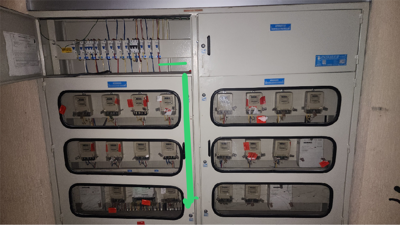

Imagen 2 (972x548)


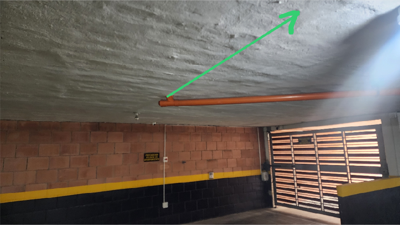

Imagen 3 (972x548)


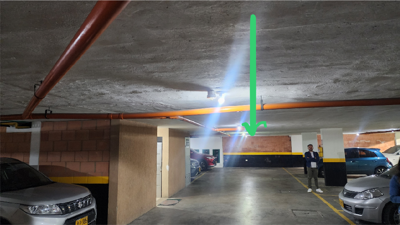

Imagen 4 (972x548)


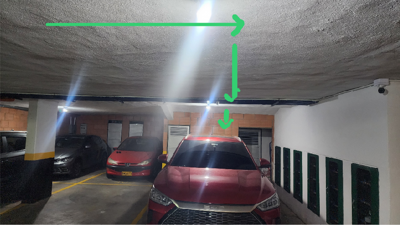

In [12]:
from IPython.display import display

def show_images(images, max_width=400):
    """Muestra una lista de imágenes PIL en el notebook."""
    for i, img in enumerate(images):
        print(f"Imagen {i + 1} ({img.size[0]}x{img.size[1]})")
        img_copy = img.copy()
        if img_copy.width > max_width:
            ratio = max_width / img_copy.width
            img_copy = img_copy.resize((max_width, int(img_copy.height * ratio)))
        display(img_copy)

show_images(content.images)

In [15]:
from llm_client import extract_data
from products.products import build_products, flatten_cotization, parse_price, Product
from pathlib import Path

In [14]:
provider = "minimax"

In [16]:
data = extract_data(
    text=content.text,
    file_path=content.source,
    provider=provider,
)

print("[LLM PROVIDER DATA] Datos extraídos")

flat_config_path = flatten_cotization()
price_flat = extract_data(
    text=content.text,
    file_path=content.source,
    provider=provider,
    data_path=flat_config_path,
    prompt_path="config/prompt_cotizacion.md",
)
Path(flat_config_path).unlink(missing_ok=True)

price = parse_price(price_flat)
products = build_products(price)

[LLM PROVIDER DATA] Datos extraídos


In [17]:
print(price)
print(*products, sep="\n")

{'cotizacion': {'costo_total': 2300000, 'metros': 27}, 'tiene_nema_14_50': {'incluido': False, 'costo': 250000}, 'tiene_wallbox': {'incluido': False, 'costo': 250000}}
Product(item=1, qty=27, desc='Instalación de estación de carga incluido cable de cobre, tubería EMT, Protección Termo Magnética, Protección diferencial Caja Mini incluye tesla nema 14-50', unit='metros', vr_uni_inc=2300000, iva=437000.0, vr_total=2737000.0)


# GENERAR DOCUMENTO

In [ ]:
import math
from docxtpl import DocxTemplate, RichText
from datetime import date
import re
import tempfile
import fcntl
import json
from pathlib import Path
from docx import Document

_MESES = [
    "enero", "febrero", "marzo", "abril", "mayo", "junio",
    "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre",
]

def _fmt(n) -> str:
    """Formatea un número como entero con separador de miles (.)."""
    return f"{int(n):,}".replace(",", ".")


_IF_BLOCK = re.compile(r'\{%-?\s*if\s+\w+\s*-?%\}.*\{%-?\s*endif\s*-?%\}', re.DOTALL)
_SENTINEL = "\u00abCOND\u00bb"  # «COND» — marca párrafos condicionales

CONFIG_PATH = Path("config/data.json")


def _increment_quote_number() -> str:
    """Atomically reads and increments the quote number in config/data.json.
    Uses file locking to prevent race conditions."""
    lock_path = CONFIG_PATH.with_suffix(".lock")
    with open(lock_path, "w") as lockf:
        fcntl.flock(lockf.fileno(), fcntl.LOCK_EX)
        try:
            with open(CONFIG_PATH, "r") as f:
                config = json.load(f)
            current = int(config.get("number", "0"))
            new_number = str(current + 1)
            config["number"] = new_number
            tmp_path = CONFIG_PATH.with_suffix(".tmp")
            with open(tmp_path, "w") as f:
                json.dump(config, f, indent=2)
            Path(tmp_path).replace(CONFIG_PATH)
            return new_number
        finally:
            fcntl.flock(lockf.fileno(), fcntl.LOCK_UN)


def _prepare_template(template_path: str) -> str:
    """Copia el template a un temporal añadiendo el sentinel al inicio
    de cada párrafo condicional {% if %}...{% endif %}.
    Retorna la ruta del archivo temporal."""
    doc = Document(str(template_path))
    for para in doc.paragraphs:
        if _IF_BLOCK.search(para.text) and para.runs:
            para.runs[0].text = _SENTINEL + para.runs[0].text
    fd, tmp = tempfile.mkstemp(suffix=".docx")
    import os; os.close(fd)
    doc.save(tmp)
    return tmp


def _remove_null_paragraphs(output_path: Path):
    """Elimina párrafos donde el sentinel quedó solo (condición False)
    y limpia el sentinel de los párrafos donde la condición fue True."""
    doc = Document(str(output_path))
    to_remove = []
    for para in doc.paragraphs:
        if para.text.strip() == _SENTINEL:
            to_remove.append(para)
        elif _SENTINEL in para.text:
            for run in para.runs:
                if _SENTINEL in run.text:
                    run.text = run.text.replace(_SENTINEL, "")
                    break
    for para in to_remove:
        para._element.getparent().remove(para._element)
    doc.save(str(output_path))


def fill_template(
    data: dict,
    products: list,
    template_path: str = "config/template_base.docx",
    output_dir: str = "pruebas",
    fotos: list[dict] | None = None,
) -> Path:
    """Rellena template_base.docx con los datos extraídos y guarda el resultado."""
    tmp_template = _prepare_template(template_path)

    try:
        tpl = DocxTemplate(tmp_template)

        hoy = date.today()
        fecha = f"{hoy.day} de {_MESES[hoy.month - 1]} de {hoy.year}"

        ciudad_dep = data.get("ciudad_departtamento") or data.get("ciudad_departamento") or "Bogotá D.C."
        ciudad = ciudad_dep.split(",")[0].strip()

        total_iva = sum(p.iva for p in products)
        valor_total = sum(p.vr_total for p in products)
        valor_inicial = math.floor(valor_total / 2 / 100_000) * 100_000
        number = _increment_quote_number()

        context = {
            "NOMBRE":              (data.get("nombre") or "").upper(),
            "is_male":             "Señor" if data.get("is_male", True) else "Señora",
            "direccion":           data.get("direccion", ""),
            "apartamento":         data.get("apartamento"),
            "nombre_edificio":     data.get("nombre_edificio"),
            "ciudad_departamento": ciudad_dep,
            "ciudad":              ciudad,
            "fecha":               fecha,
            "date":                hoy.strftime("%Y-%m-%d"),
            "tipo_vehiculo":       data.get("tipo_vehiculo") or "Tesla",
            "fotos":               fotos or [],
            "new_page":            RichText("\f"),
            "number":              number,
            "products":            [
                type("P", (), dict(
                    item=p.item, qty=p.qty, desc=p.desc, unit=p.unit,
                    value=_fmt(p.value), iva=_fmt(p.iva), vr_total=_fmt(p.vr_total)
                ))() for p in products
            ],
            "total_iva":           _fmt(total_iva),
            "valor_total":         _fmt(valor_total),
            "valor_inicial":        f"{valor_inicial:,}",
        }

        tpl.render(context)

        direccion_slug = re.sub(r'[^\w\s-]', '', data.get("direccion", "documento")).strip().replace(" ", "_")
        timestamp = hoy.strftime("%Y%m%d")
        output_path = Path(output_dir) / f"{direccion_slug}_{timestamp}.docx"
        tpl.save(output_path)
    finally:
        Path(tmp_template).unlink(missing_ok=True)

    _remove_null_paragraphs(output_path)
    return output_path

In [ ]:
print(data)
products[0].vr_total = 3568000
print(*products)

In [ ]:
output_file = fill_template(data, products)
print(f"Archivo generado: {output_file}")